In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

color_list = ['#0072b2', '#009e73', '#e69f00', '#d55e00',
              '#f0e442','#cc79a7', '#56b4e9', '#000000']

#   Evolution of the energy distribution as function of the dissipation 

95
62370


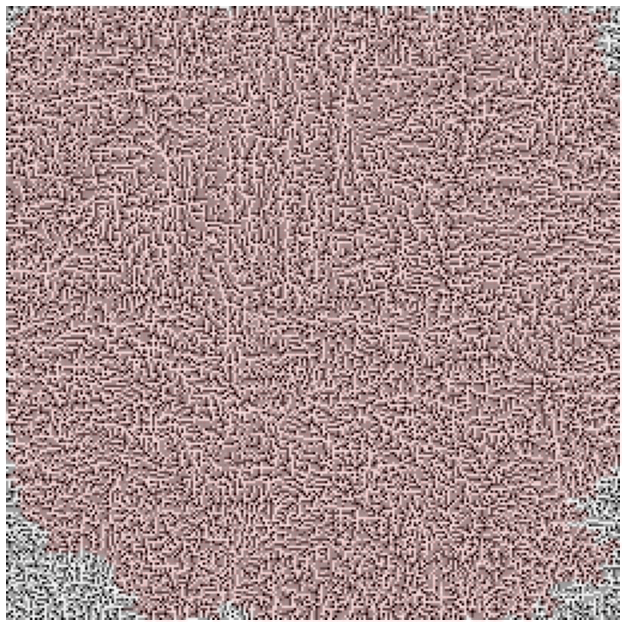

89
28476


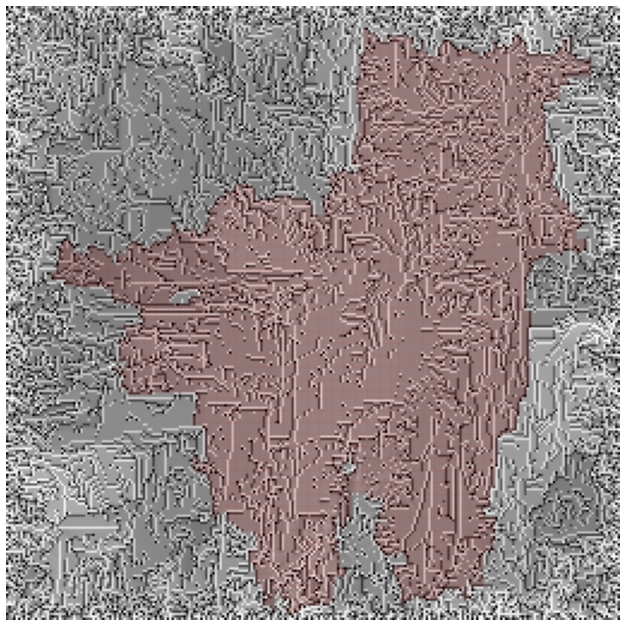

62
21739


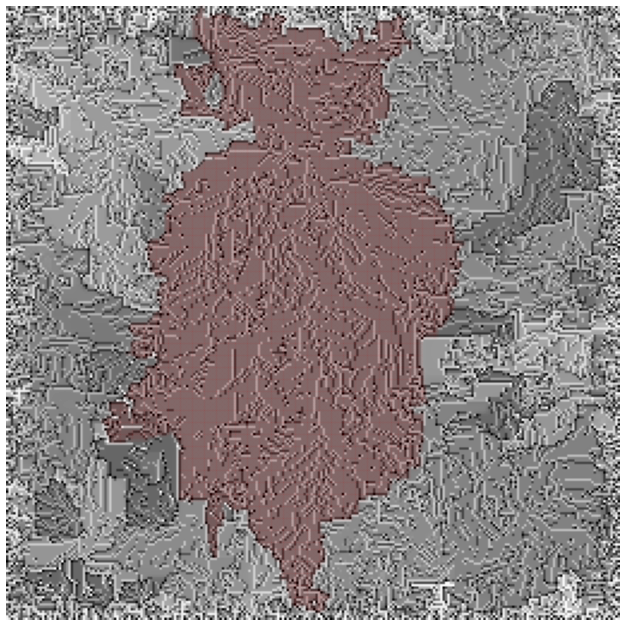

6
15241


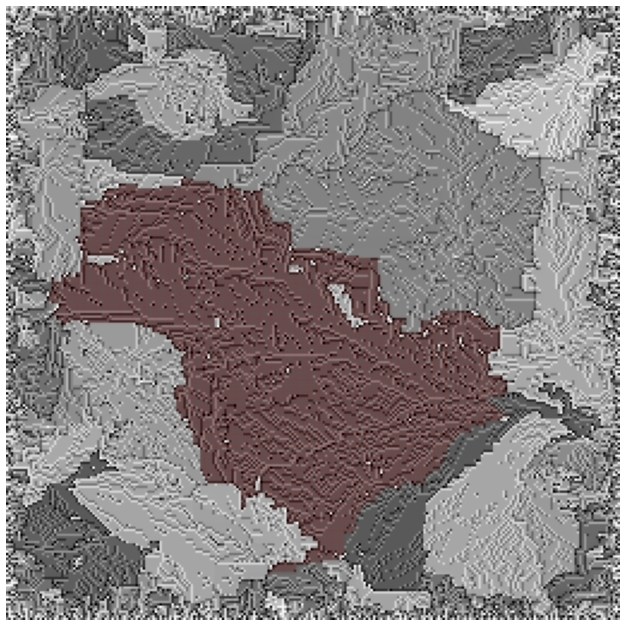

72
12895


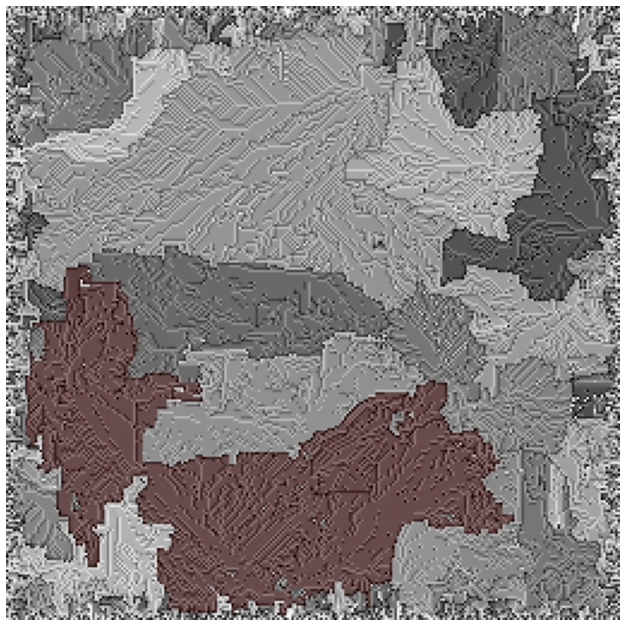

141
9254


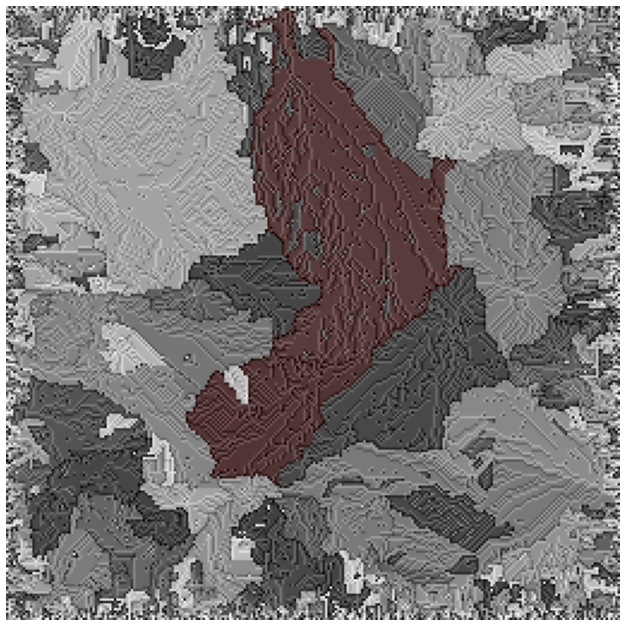

In [267]:
for j in range(1,7):

    folderpath ="/data1/DATA_Duplat/Brut/Ava_track/Av6n{}".format(j)
    file = f"{folderpath}/shape_outputB10.txt"

    L1 = read_parameters(folderpath)[0]
    L2 = read_parameters(folderpath)[1]
    
    nbava = 200
    Noava = []
    data = []
    id_max = 0
    maxlen = 0
    
    with open(file) as f:
        
        for i, line in enumerate(f):
            if line.startswith("#"):
                continue
            id = line.strip().split()[0]
            col = np.array(line.strip().split()[3:], dtype=int)
            y, x = coorno(col, L1)
            
            coo = np.column_stack((x, y))
            data.append(coo.tolist())
            Noava.append(id)
            if maxlen <= len(col):
                maxlen = len(col)
                id_max = i-2
            if i == nbava:
                break
            
    print(id_max)
    print(len(data[id_max]))
    ava = np.array(data[id_max])
    y = ava[:, 0]
    x = ava[:, 1]
    
    snapfile = "{}/Snapshots/nav{}_outputB.txt".format(folderpath, Noava[id_max])
    snap = np.loadtxt(snapfile, comments="#").reshape(L1, L2)
    
    
    mask = np.zeros_like(snap, dtype = bool)
    mask[y,x] = True
    systembis = np.where(mask, snap, np.nan)
    
    fig, ax1 = plt.subplots(1,1, figsize = (8,8))
    ax1.imshow(snap, cmap = "binary")
    ax1.scatter(x, y, c = 'r', alpha = 0.02, s = 10)
    ax1.set_xlim(-1, L1)
    ax1.set_ylim(-1, L2)
    ax1.set_axis_off()
    plt.show()
    

95
89
62
6
72
147


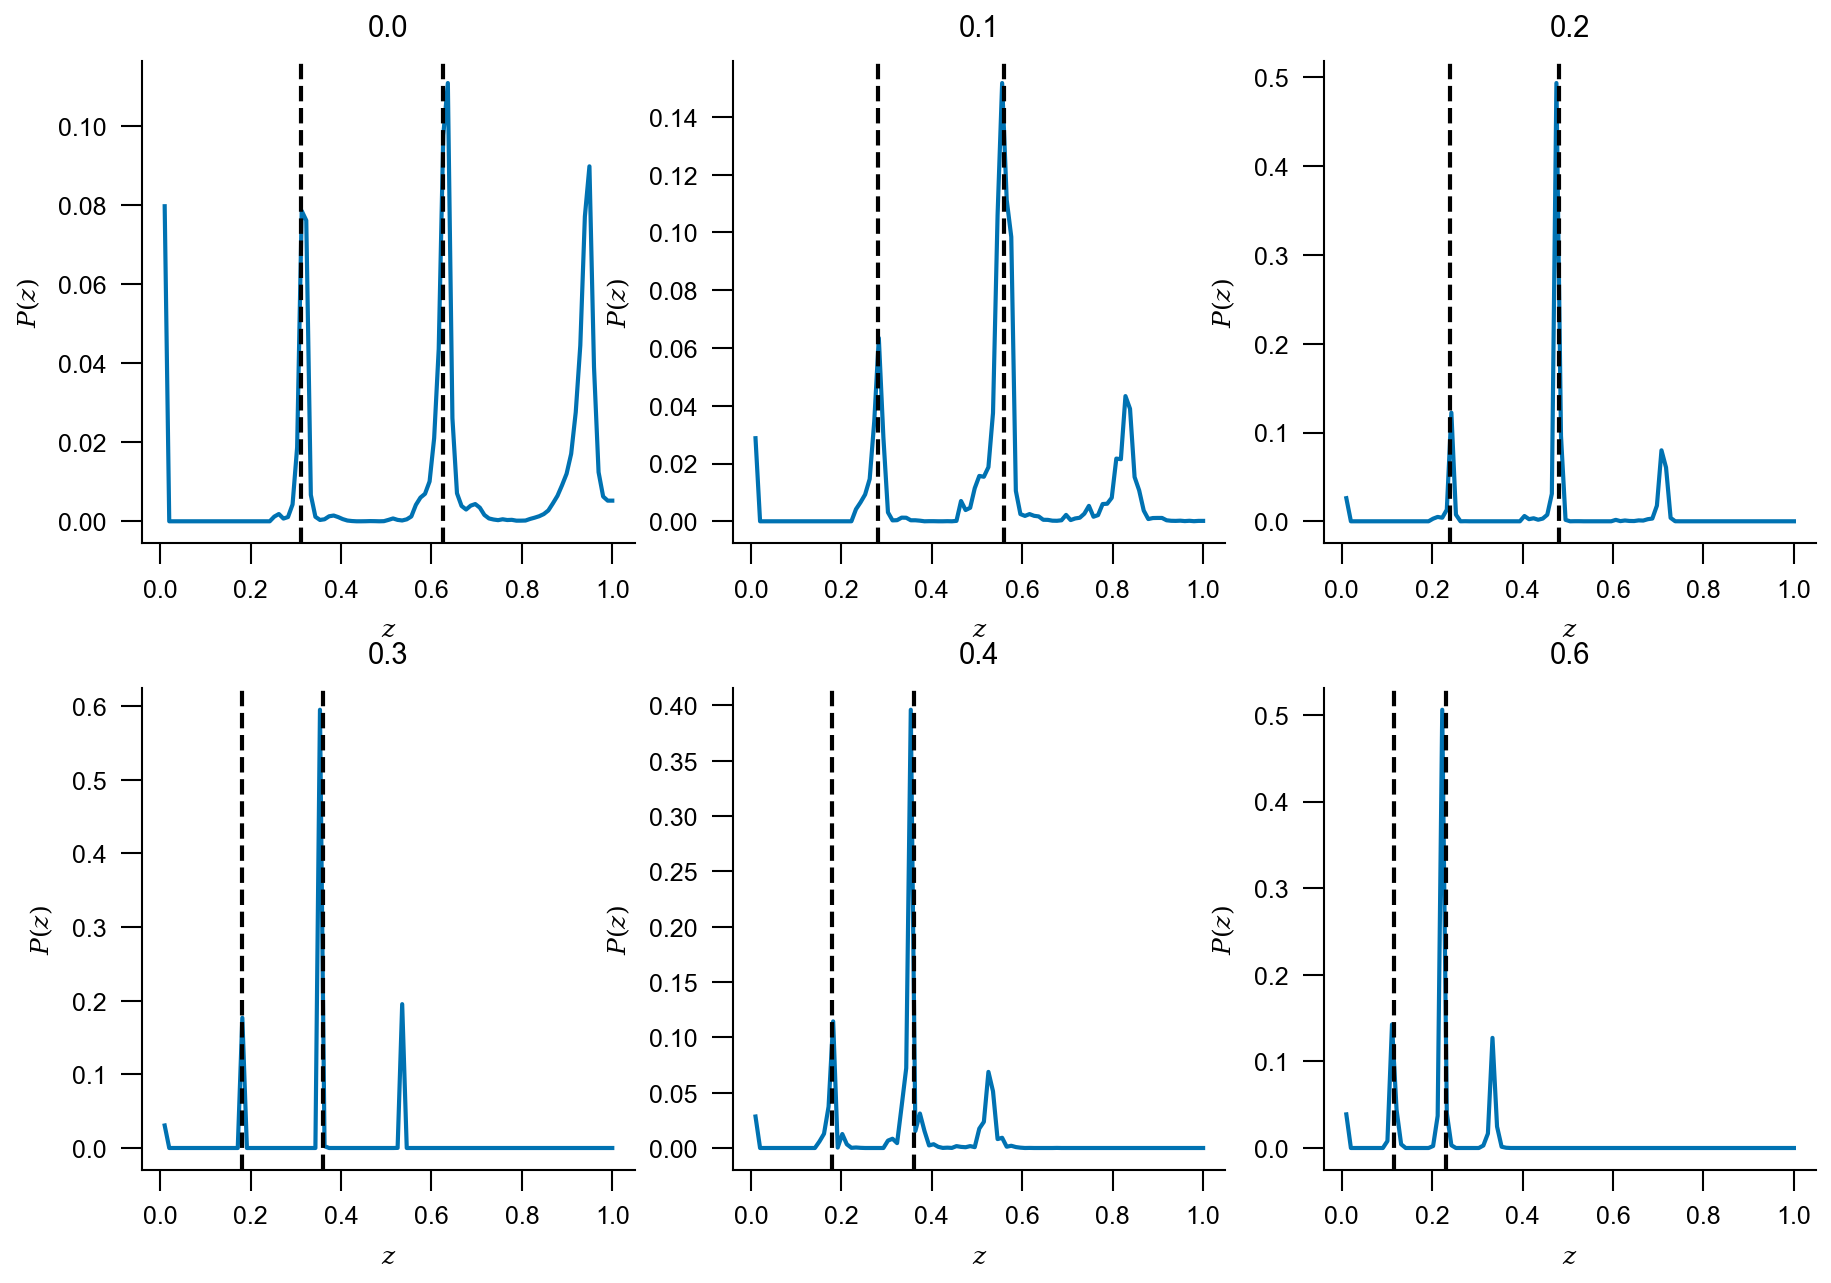

In [9]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, axs = plt.subplots(2,3, figsize = (7.2,4.8))
    plt.subplots_adjust(hspace=0.3)
    axs = axs.flatten()
    
    nofolder = [1,2,3,4,5,7]

    for k, j in enumerate(nofolder):
        
        folderpath ="/data1/DATA_Duplat/Brut/Ava_track/Av6n{}".format(j)
        file = f"{folderpath}/shape_outputB10.txt"

        L1 = read_parameters(folderpath)[0]
        L2 = read_parameters(folderpath)[1]
        nu = read_parameters(folderpath)[2]
        
        nbava = 200
        Noava = []
        data = []
        
        id_max = 0
        maxlen = 0
        
        with open(file) as f:
            for i, line in enumerate(f):
                if line.startswith("#"):
                    continue
                col = line.strip().split()[3:]
                id = line.strip().split()[0]
                col = np.array(col, dtype=int)
                y, x = coorno(col, L1)
                
                coo = np.column_stack((x, y))
                data.append(coo.tolist())
                Noava.append(id)
                if maxlen < len(coo):
                    maxlen = len(coo)
                    id_max = i-2
                
                if i == nbava:
                    break
        print(id_max)
        ava = np.array(data[id_max])
        y = ava[:, 0]
        x = ava[:, 1]
        
        snapfile = "{}/Snapshots/nav{}_outputB.txt".format(folderpath, Noava[id_max])
        snap = np.loadtxt(snapfile, comments="#").reshape(L1, L2)
        
        
        mask = np.zeros_like(snap, dtype = bool)
        mask[y,x] = True
        systembis = np.where(mask, snap, np.nan)
        
        histo, bins = np.histogram(systembis, bins = np.linspace(0,1,100))

        axs[k].plot(1-bins[:-1], histo/np.sum(histo), c = color_list[0])
        axs[k].set_xlabel(r"$z$")
        axs[k].set_ylabel(r"$P(z)$")
        axs[k].set_title(nu)
        
    axs[0].axvline(0.3125, ls = '--', c = 'k')
    axs[0].axvline(0.625, ls = '--', c = 'k')
    axs[1].axvline(0.28, ls = '--', c = 'k')
    axs[1].axvline(0.56, ls = '--', c = 'k')
    axs[2].axvline(0.24, ls = '--', c = 'k')
    axs[2].axvline(0.48, ls = '--', c = 'k')
    axs[3].axvline(0.18, ls = '--', c = 'k')
    axs[3].axvline(0.36, ls = '--', c = 'k')
    axs[4].axvline(0.18, ls = '--', c = 'k')
    axs[4].axvline(0.36, ls = '--', c = 'k')
    axs[5].axvline(0.115, ls = '--', c = 'k')
    axs[5].axvline(0.23, ls = '--', c = 'k')
    plt.show()

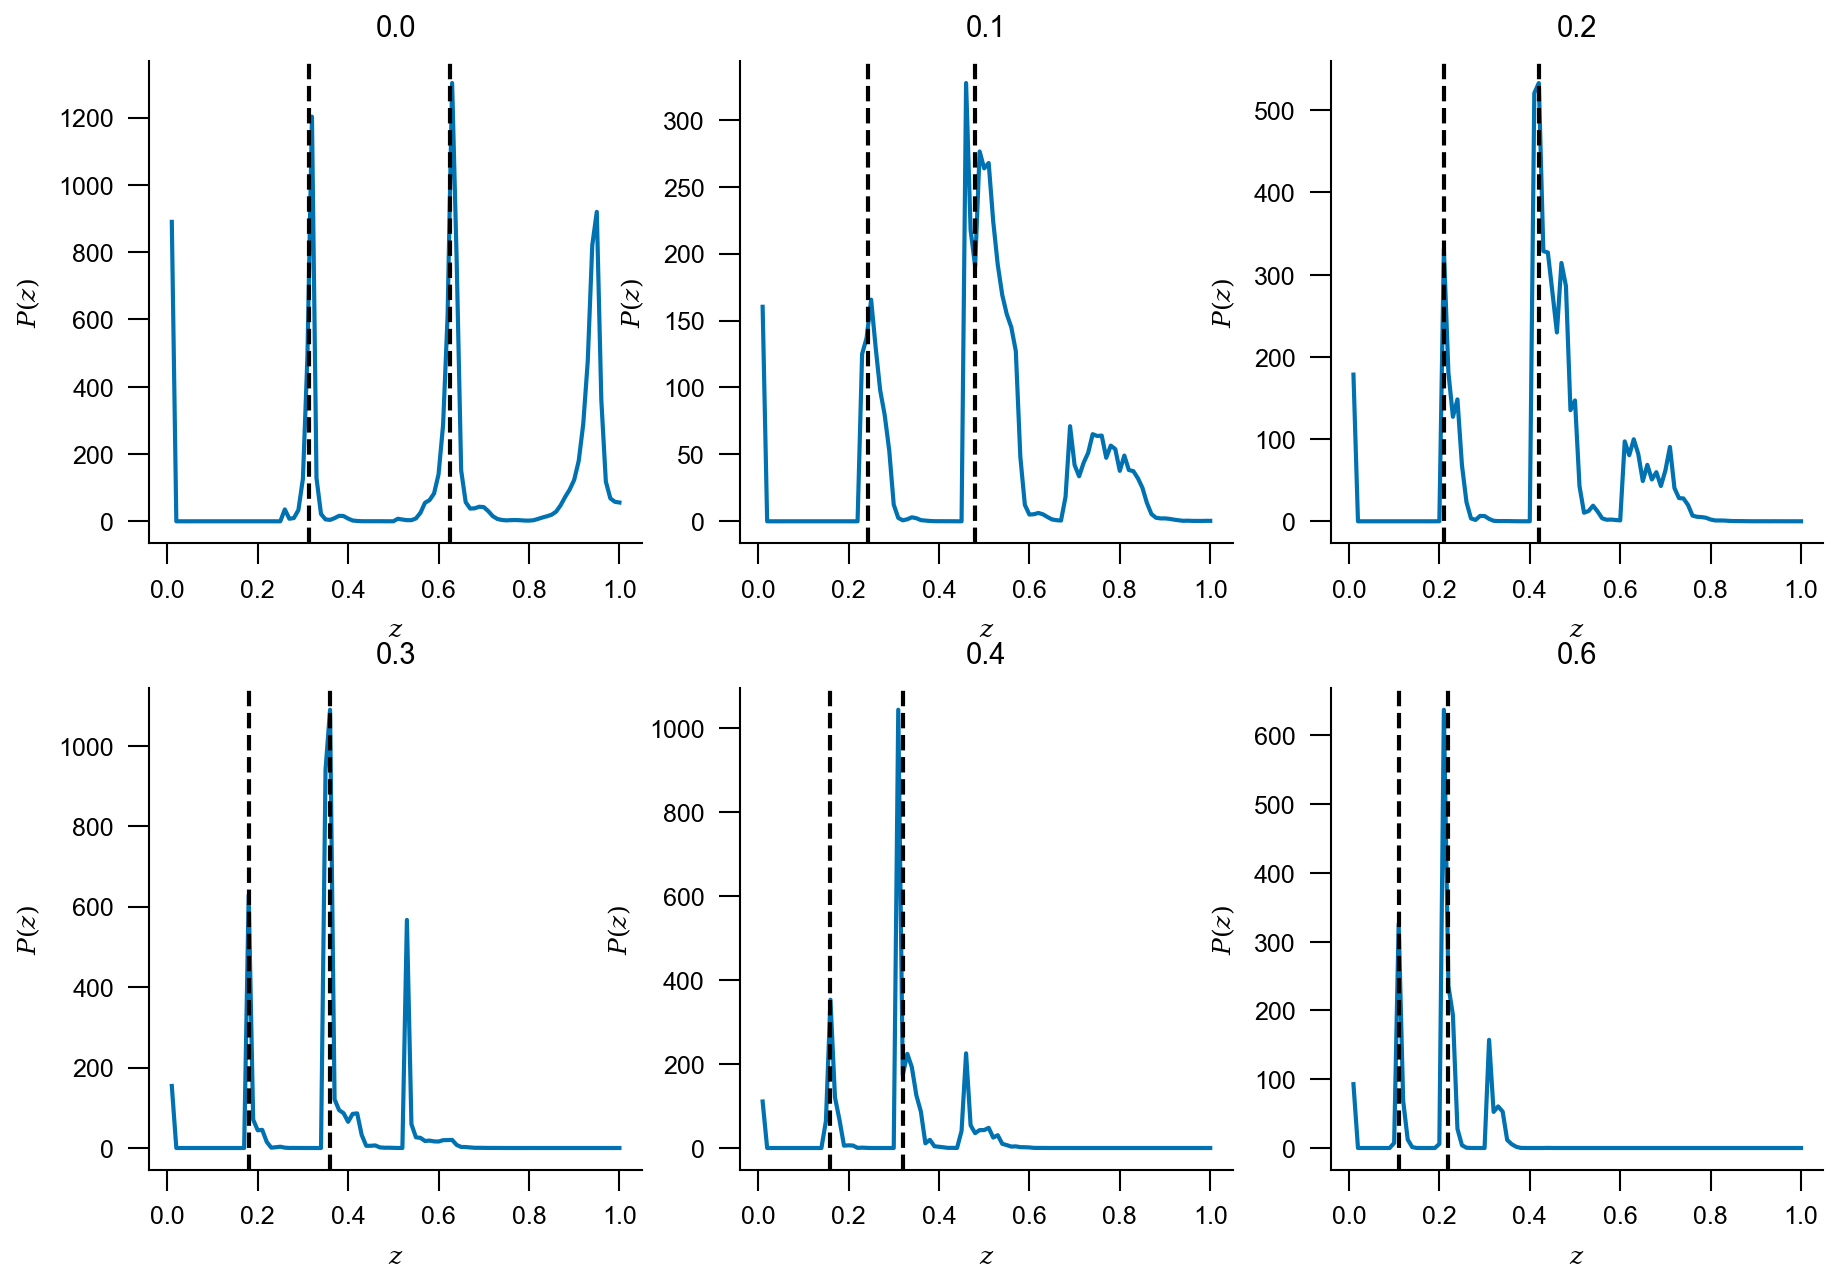

In [15]:
with plt.style.context(spstyle.get_style('nature-reviews')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, axs = plt.subplots(2,3, figsize = (7.2,4.8))
    plt.subplots_adjust(hspace=0.3)
    axs = axs.flatten()
    
    nofolder = [1,2,3,4,5,7]

    for k, j in enumerate(nofolder):
        
        folderpath ="/data1/DATA_Duplat/Brut/Ava_track/Av6n{}".format(j)
        file = f"{folderpath}/shape_outputB10.txt"

        L1 = read_parameters(folderpath)[0]
        L2 = read_parameters(folderpath)[1]
        nu = read_parameters(folderpath)[2]
        
        nbava = 200
        
        nbins= 100
        histo = np.zeros(nbins)
        bins = np.linspace(0,1,nbins+1)
        count = 0
        with open(file) as f:
            for i, line in enumerate(f):
                if line.startswith("#"):
                    continue
                col = line.strip().split()[3:]
                id = line.strip().split()[0]
                col = np.array(col, dtype=int)
                y, x = coorno(col, L1)
                
                snapfile = "{}/Snapshots/nav{}_outputB.txt".format(folderpath, id)
                snap = np.loadtxt(snapfile, comments="#").reshape(L1, L2)
        
                mask = np.zeros_like(snap, dtype = bool)
                mask[x,y] = True
                systembis = np.where(mask, snap, np.nan)
                
                histo += np.histogram(systembis, bins = bins)[0]
                count += 1
                if i == nbava:
                    break
        

        axs[k].plot(1-bins[:-1], histo/count, c = color_list[0])
        axs[k].set_xlabel(r"$z$")
        axs[k].set_ylabel(r"$P(z)$")
        axs[k].set_title(nu)
        
    axs[0].axvline(0.3125, ls = '--', c = 'k')
    axs[0].axvline(0.625, ls = '--', c = 'k')
    axs[1].axvline(0.243, ls = '--', c = 'k')
    axs[1].axvline(0.48, ls = '--', c = 'k')
    axs[2].axvline(0.21, ls = '--', c = 'k')
    axs[2].axvline(0.42, ls = '--', c = 'k')
    axs[3].axvline(0.18, ls = '--', c = 'k')
    axs[3].axvline(0.36, ls = '--', c = 'k')
    axs[4].axvline(0.16, ls = '--', c = 'k')
    axs[4].axvline(0.32, ls = '--', c = 'k')
    axs[5].axvline(0.11, ls = '--', c = 'k')
    axs[5].axvline(0.22, ls = '--', c = 'k')
    plt.show()

#   We create new configuration from a conservative snapshot

(256, 256)


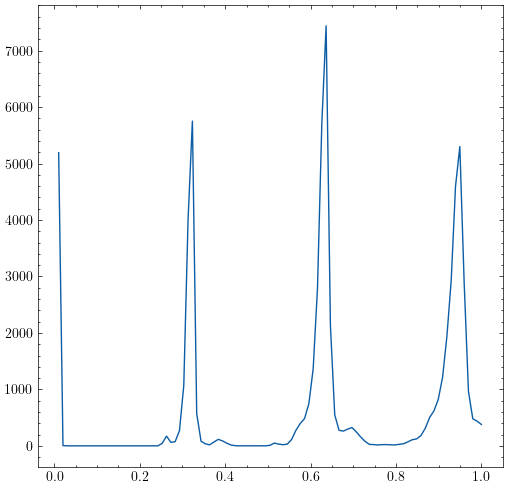

In [85]:
folder = "/data1/DATA_Duplat/Brut/PDF/PD5n1"
params= read_parameters(folder)
L1 = params[0]
L2 = params[1]
snap = np.loadtxt("{}/Snapshots/nav1000000000_outputB.txt".format(folder), comments="#").reshape(L1, L2).T
print(np.shape(snap))

histo, bins = np.histogram(snap, bins = np.linspace(0,1,100))

fig, ax = plt.subplots(figsize = (6,6))
ax.plot(1-bins[:-1], histo)
plt.show()

In [86]:
# def gaussian_fixed_mean(mu=1.0, sigma=0.02, N=1000):
#     x = np.random.normal(mu, sigma, N)
#     x = np.minimum(x, 1)
#     x = np.maximum(x, 0)
#     x += (mu - x.mean())   # recentrage exact
#     x = np.maximum(x, 0)
#     x = np.minimum(x, 1)
#     return x

def gaussian_fixed_mean(mu, sigma, N):
    x = np.random.normal(mu, sigma, N)
    x = np.clip(x, 0.0, 1.0)
    x += mu - x.mean()          # recentrage exact
    return np.clip(x, 0.0, 1.0)

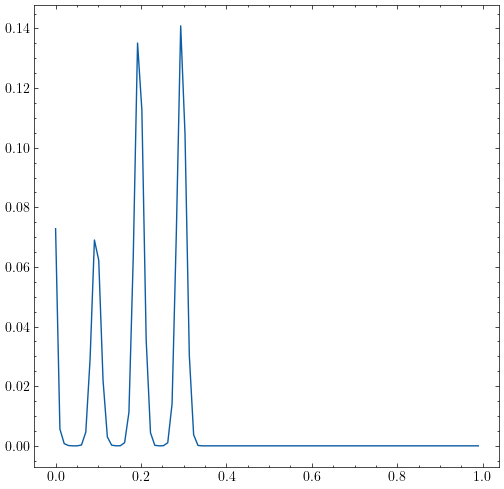

In [87]:
snap_mask = np.zeros_like(snap)

# mask1 = snap >= 0.85
# mask2 = (snap >= 0.52) & (snap <0.85)
# mask3 = (snap >= 0.25) & (snap <0.52)
# mask4 = snap < 0.25

# snap_mask[mask1] = 1
# snap_mask[mask2] = 2
# snap_mask[mask3] = 3
# snap_mask[mask4] = 4
# print(snap_mask)

bins = [0.25, 0.52, 0.85]
snap_mask = (4 - np.digitize(snap, bins)).astype(float)
delta = 0.1


redraw_sys = np.zeros_like(snap_mask)
for k in [1,2,3,4]:
    mask = snap_mask == k
    redraw_sys[mask] = gaussian_fixed_mean((k-1)*delta, 0.01, mask.sum())



histo, bins = np.histogram(redraw_sys, bins = np.linspace(0,1,100))
fig, ax = plt.subplots(figsize = (6,6))
ax.plot(bins[:-1], histo/np.sum(histo))
plt.show()

In [ ]:
# for i in range(nbsection):
#     n = int(i%(L1/x_div))
#     m = int(i//(L1/x_div))
#     xmin = x_div * n
#     xmax = x_div * (n+1)
#     ymin = y_div * m
#     ymax = y_div * (m+1) 
    
#     Tsection[i] = snap_mask[xmin:xmax, ymin:ymax]
    
nx = 4   #Must be a power of 4
ny = 4
x_div = L1 // nx
y_div = L2 // ny

#On fait 2 ligne de 2 colonne d'élément de 2 ligne 2 colonne 
#On peut aussi voir ça comme un quadtree:
#Niveau 0: redraw_sys[:,:,:,:,]
#Niveau 1: redraw_sys[n, :, m, :] n et m le nombre carré par ligne et de colonne
#Niveau 1: redraw_sys[n, i, m, j] i et j le nombre site par de ligne et de colonne dans chaque élément
#.swapaxes(1,2) change l'axe 1 et 2 pour que ce soit plus simple à manipulé
Tsection = redraw_sys.reshape(nx, x_div, ny, y_div).swapaxes(1,2)
print(np.shape(Tsection))
#Supprime une dimension pour faire des carrés
Tsection = Tsection.reshape(-1, x_div, y_div)
print(np.shape(Tsection))

(4, 4, 64, 64)
(16, 64, 64)


In [100]:
# import random
# new_snap = np.zeros_like(snap)
# for i in range(nbsection):
#     n = int(i%(L1/x_div))
#     m = int(i//(L1/x_div))
#     xmin = x_div * n
#     xmax = x_div * (n+1)
#     ymin = y_div * m
#     ymax = y_div * (m+1) 
    
#     id = random.randint(0, nbsection-1)
#     tilt = random.uniform(np.max(Tsection[id]),1) - np.max(Tsection[id])
#     new_snap[xmin:xmax, ymin:ymax] = Tsection[id] + tilt
    
# np.savetxt("New_config.txt",new_snap.flatten().T)

nbsection = len(Tsection)
ids = np.random.permutation(nbsection)  #Prend des valeurs uniques entre 0 et nbsections

max_vals = Tsection[ids].max(axis=(1,2)) #Trouve les maxs sur les axes 1 et 2 
tilts = np.random.uniform(max_vals, 1.0) - max_vals
new_blocks = Tsection[ids] + tilts.reshape(-1, 1, 1) #Applique le tilt à tous éléments de chaque partie
print(np.shape(new_blocks))
new_snap = new_blocks.reshape(nx, ny, x_div, y_div).swapaxes(1,2) #On remet en carré correct pour récup la forme du sys
new_snap = new_snap.reshape(L1, L2) #On remet en  forme du sys


(16, 64, 64)


In [101]:
print(np.min(new_snap),np.max(new_snap))

0.12161089285296073 0.9937727178408435


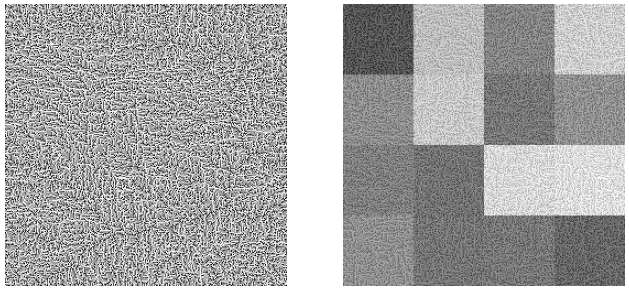

In [102]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (8,8))
ax1.imshow(snap, cmap = 'binary', vmin = 0, vmax = 1)
ax2.imshow(new_snap, cmap = 'gray', vmin = 0, vmax = 1)

ax1.set_axis_off()
ax2.set_axis_off()
plt.savefig("Snap_comp.pdf", dpi = 600)
plt.show()